# L3A · Gradient descent geometry on quadratics

**One idea:** the Hessian's eigenvalue *spread* (condition number) controls GD.
Circular contours ($x^2+y^2$) descend straight in; elongated contours
($x^2+10y^2$) make GD **zigzag**.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(0)

def run_gd(gamma, lr, steps=40, start=(9.0, 1.0)):
    p = np.array(start, dtype=float)
    path = [p.copy()]
    for _ in range(steps):
        grad = np.array([2*p[0], 2*gamma*p[1]])   # f = x^2 + gamma*y^2
        p = p - lr*grad
        path.append(p.copy())
    return np.array(path)

path_circ = run_gd(gamma=1,  lr=0.1)
path_elong = run_gd(gamma=10, lr=0.09)
print("well-conditioned final:", np.round(path_circ[-1], 4))
print("ill-conditioned  final:", np.round(path_elong[-1], 4))

well-conditioned final: [0.0012 0.0001]
ill-conditioned  final: [0.0032 0.0001]


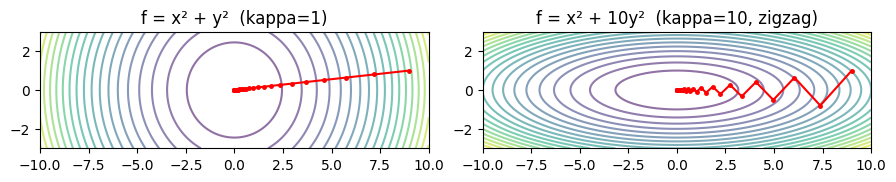

In [2]:
fig, ax = plt.subplots(1, 2, figsize=(9, 3.8))
for a, gamma, path, title in [
        (ax[0], 1,  path_circ,  "f = x² + y²  (kappa=1)"),
        (ax[1], 10, path_elong, "f = x² + 10y²  (kappa=10, zigzag)")]:
    gx, gy = np.meshgrid(np.linspace(-10, 10, 200), np.linspace(-3, 3, 200))
    a.contour(gx, gy, gx**2 + gamma*gy**2, levels=20, cmap="viridis", alpha=0.6)
    a.plot(path[:,0], path[:,1], "r.-", ms=5)
    a.set_title(title); a.set_aspect("equal", "box")
plt.tight_layout(); plt.show()

## Takeaway
- GD steps point along $-\nabla f$, which is **not** the direction to the minimum
  unless the contours are circular.
- **Ill-conditioning** (large curvature in one direction, small in another) makes
  first-order GD zigzag and converge slowly — the motivation for momentum / Adam.